In [33]:
# Descriptive Statistics

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from tabulate import tabulate

# Step 2: Load the cleaned Excel file
file_path = "walmart-sales-dataset-of-45stores.csv"
df = pd.read_csv(file_path)

# Step 3: Define the columns to analyze
columns_to_analyze = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Step 4: Create an empty dictionary to store statistics
stats_rows = {
    'Count': [],
    'Minimum': [],
    'Maximum': [],
    'Mean': [],
    'Median': [],
    'Mode': [],
    'Variance': [],
    'Standard Deviation': [],
    '25th Percentile': [],
    '50th Percentile': [],
    '75th Percentile': [],
    'Kurtosis': [],
    'Skewness': [],
    'IQR': []
}

# Step 5: Loop through each column and compute statistics
for col in columns_to_analyze:
    data = df[col].dropna()
    stats_rows['Count'].append(data.count())
    stats_rows['Minimum'].append(data.min())
    stats_rows['Maximum'].append(data.max())
    stats_rows['Mean'].append(data.mean())
    stats_rows['Median'].append(data.median())
    stats_rows['Mode'].append(data.mode().iloc[0] if not data.mode().empty else np.nan)
    stats_rows['Variance'].append(data.var())
    stats_rows['Standard Deviation'].append(data.std())
    stats_rows['25th Percentile'].append(data.quantile(0.25))
    stats_rows['50th Percentile'].append(data.quantile(0.50))
    stats_rows['75th Percentile'].append(data.quantile(0.75))
    stats_rows['Kurtosis'].append(kurtosis(data))
    stats_rows['Skewness'].append(skew(data))
    stats_rows['IQR'].append(data.quantile(0.75) - data.quantile(0.25))

# Step 6: Convert the dictionary to a DataFrame
stats_df = pd.DataFrame(stats_rows, index=columns_to_analyze).T  # Transpose to get stats as rows

# Step 7: Print the summary in tabulated form
print("\n Descriptive Statistics Summary (For 45 Stores)")
print(tabulate(stats_df, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Step 8: Export the summary to Excel
output_file = "Walmart_Stats.xlsx"
stats_df.to_excel(output_file)

# Step 9: Confirm export success
print(f"\n📁 Summary exported successfully to '{output_file}'")


 Descriptive Statistics Summary (For 45 Stores)
+--------------------+-------------------+---------------+--------------+-----------+----------------+
|                    |      Weekly_Sales |   Temperature |   Fuel_Price |       CPI |   Unemployment |
+====================+===================+===============+==============+===========+================+
| Count              |         6435.0000 |     6435.0000 |    6435.0000 | 6435.0000 |      6435.0000 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Minimum            |       209986.2500 |       -2.0600 |       2.4720 |  126.0640 |         3.8790 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Maximum            |      3818686.4500 |      100.1400 |       4.4680 |  227.2328 |        14.3130 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Mean               |  

In [34]:
#from google.colab import drive
#drive.mount('/content/drive')

## Distribution of Weekly Sales

This histogram shows the frequency distribution of weekly sales values across all stores, helping us understand the shape, spread, and central tendency of the sales data.

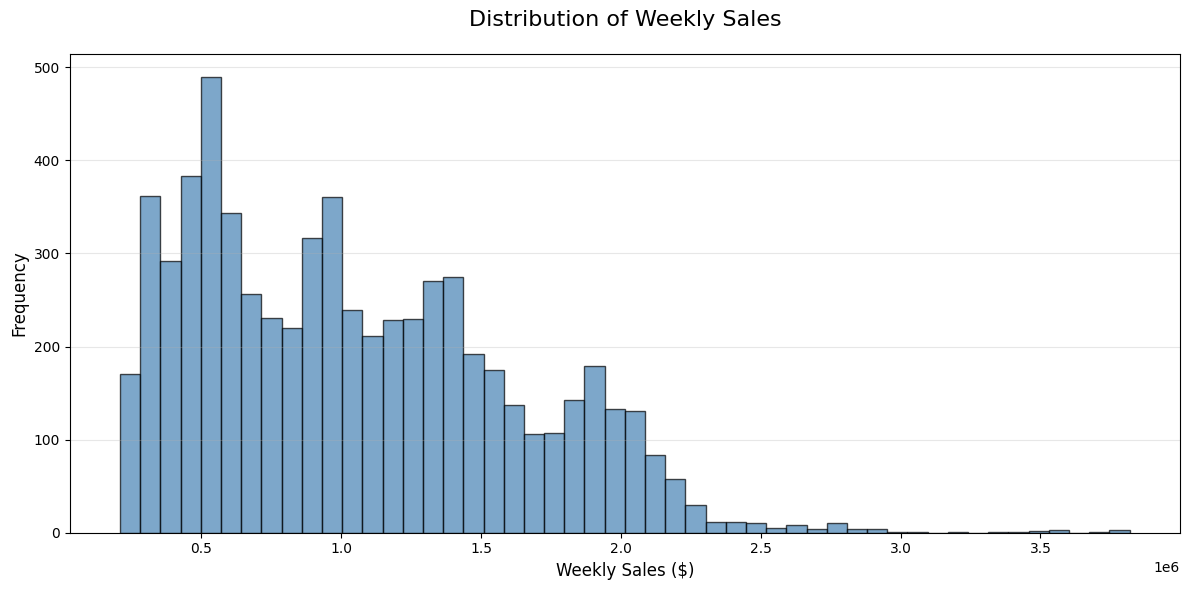

Mean: $1,046,964.88
Median: $960,746.04
Std Dev: $564,366.62


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(df['Weekly_Sales'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Weekly Sales', fontsize=16, pad=20)
plt.xlabel('Weekly Sales ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Mean: ${df['Weekly_Sales'].mean():,.2f}")
print(f"Median: ${df['Weekly_Sales'].median():,.2f}")
print(f"Std Dev: ${df['Weekly_Sales'].std():,.2f}")

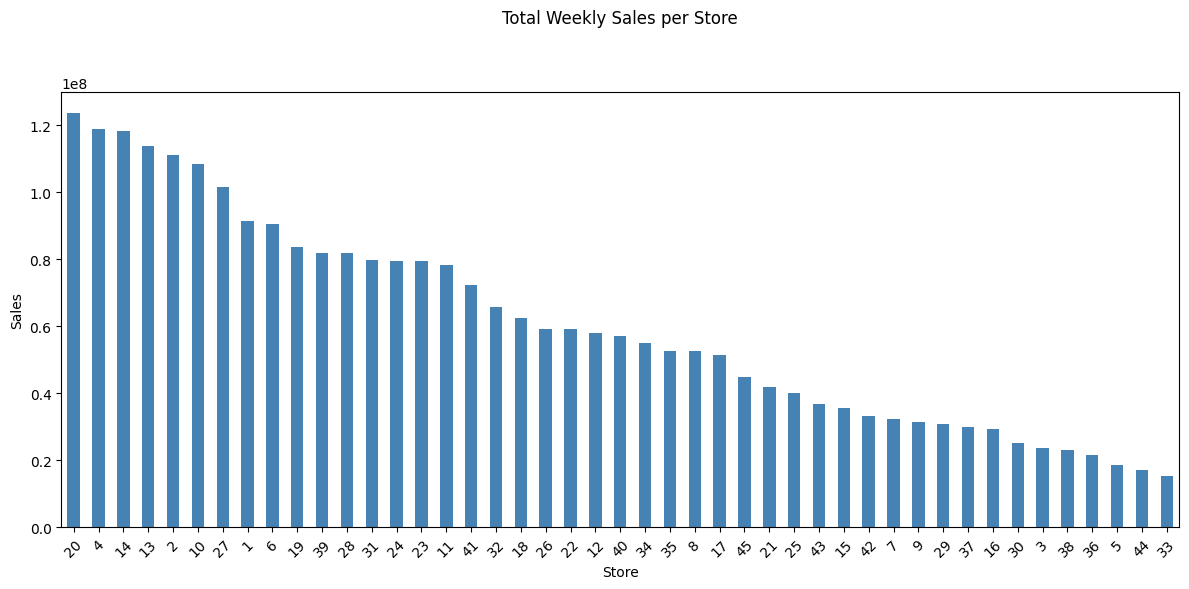

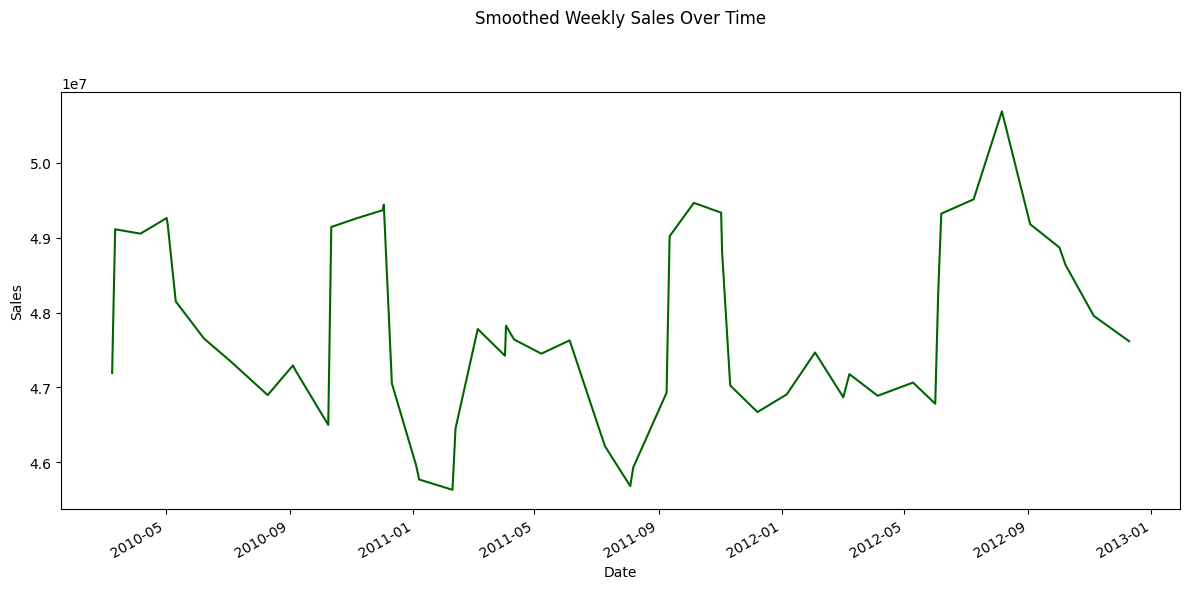

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)

# Total and average sales per store
store_sales = df.groupby('Store')['Weekly_Sales'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)

plt.figure(figsize=(12,6))
store_sales['sum'].plot(kind='bar', color='steelblue')
plt.title('Total Weekly Sales per Store', pad=50)
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekly sales over time
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
weekly_sales.rolling(window=4).mean().plot(color='darkgreen')
plt.title('Smoothed Weekly Sales Over Time', pad=50)
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

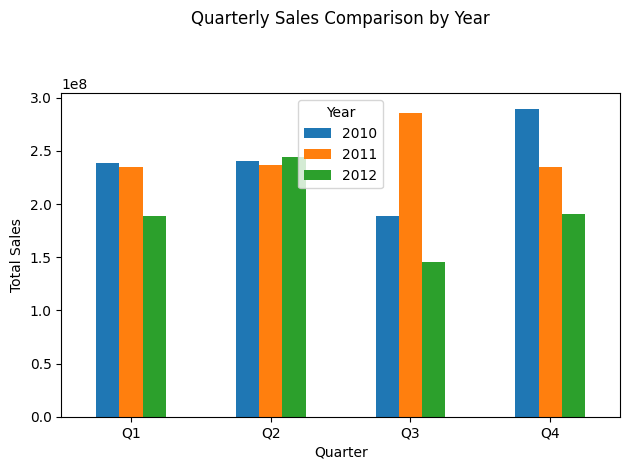

In [37]:
# Quarterly Sales Comparison by Year

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quarter'] = df['Date'].dt.to_period('Q')
df['Year'] = df['Date'].dt.year

quarterly_sales = df.groupby(['Year', 'Quarter'])['Weekly_Sales'].sum().reset_index()
quarterly_sales['Quarter_Label'] = quarterly_sales['Quarter'].astype(str).str[-2:]

pivot_quarters = quarterly_sales.pivot(index='Quarter_Label', columns='Year', values='Weekly_Sales')
pivot_quarters.index = ['Q1', 'Q2', 'Q3', 'Q4']

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
pivot_quarters.plot(kind='bar')
plt.title('Quarterly Sales Comparison by Year', pad = 50)
plt.ylabel('Total Sales')
plt.xlabel('Quarter')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [38]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define major and minor holiday dates
major_holidays = pd.to_datetime([
    '2010-11-26', '2010-12-31',
    '2011-11-25', '2011-12-30',
    '2012-11-23', '2012-12-25'
])

minor_holidays = pd.to_datetime([
    '2010-02-12', '2010-09-10',
    '2011-02-11', '2011-09-09',
    '2012-02-10', '2012-09-07'
])

# Tag holiday type
df['Holiday_Type'] = 'None'
df.loc[df['Date'].isin(minor_holidays), 'Holiday_Type'] = 'Minor'
df.loc[df['Date'].isin(major_holidays), 'Holiday_Type'] = 'Major'

In [39]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define holiday dates
major_holidays = pd.to_datetime(['2010-11-26', '2010-12-25', '2011-11-25', '2011-12-25', '2012-11-23', '2012-12-25'])
minor_holidays = pd.to_datetime(['2010-02-12', '2010-09-10', '2011-02-11', '2011-09-09', '2012-02-10', '2012-09-07'])

# Tag holiday type
df['Holiday_Type'] = 'None'
df.loc[df['Date'].isin(minor_holidays), 'Holiday_Type'] = 'Minor'
df.loc[df['Date'].isin(major_holidays), 'Holiday_Type'] = 'Major'

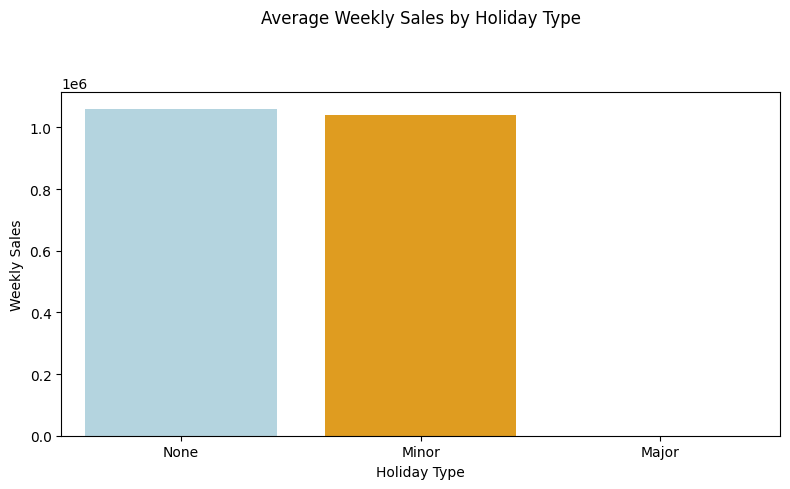

In [40]:
# Average Weekly Sales by Holiday Type

import seaborn as sns
import matplotlib.pyplot as plt

# Group by holiday type
holiday_avg = df.groupby('Holiday_Type')['Weekly_Sales'].mean().reindex(['None', 'Minor', 'Major'])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=holiday_avg.index, y=holiday_avg.values, hue=holiday_avg.index,
            palette=['lightblue', 'orange', 'red'], legend=False)
plt.title('Average Weekly Sales by Holiday Type', pad=50)
plt.ylabel('Weekly Sales')
plt.xlabel('Holiday Type')
plt.tight_layout()
plt.show()

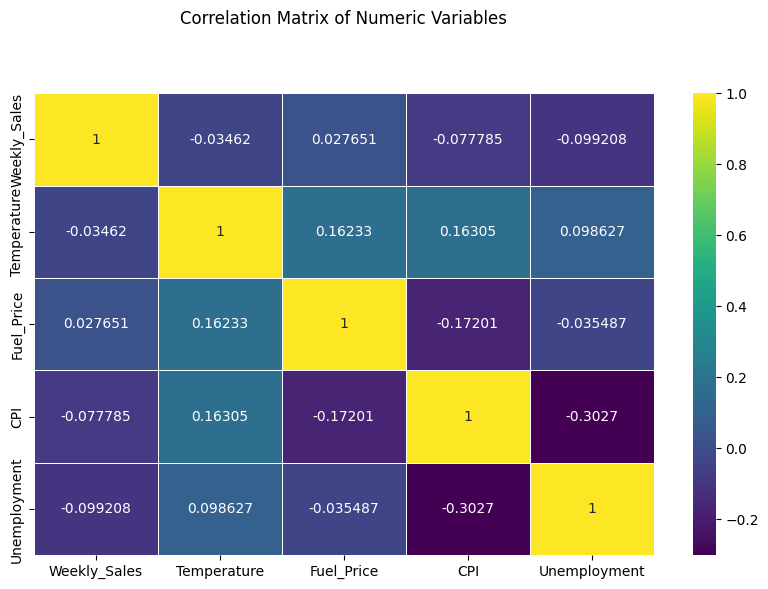

In [41]:
# Pearson correlation analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your Walmart DataFrame
# Select relevant numeric columns
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".5g", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables', pad=50)
plt.show()

## Pairplot Analysis

This pairplot shows the relationships between all numeric variables, with scatter plots for variable pairs and distribution histograms on the diagonal.

In [ ]:
# Pairplot for multivariate analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')

# Select numeric columns for pairplot
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Create pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(df[numeric_cols], diag_kind='hist', plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot of Numeric Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()